# ****Import Libraries****

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 17.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import kagglehub
import optuna

# Utilities
pd.set_option('display.max_columns', 999)
sns.set_theme(style = 'darkgrid', palette = 'pastel')

import warnings
warnings.filterwarnings('ignore')

# Set Random seeds for Reproductibility
torch.manual_seed(42)

# Check device name
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Available Device :\t{device}')

Available Device :	cuda


# ****Data Importing****

In [3]:
path = kagglehub.dataset_download("yashpalthakor/fmnist-small-csv", path = 'fmnist_small.csv')
df = pd.read_csv(path)
df.head()

100%|██████████| 12.7M/12.7M [00:01<00:00, 11.0MB/s]


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,pixel42,pixel43,pixel44,pixel45,pixel46,pixel47,pixel48,pixel49,pixel50,pixel51,pixel52,pixel53,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,pixel64,pixel65,pixel66,pixel67,pixel68,pixel69,pixel70,pixel71,pixel72,pixel73,pixel74,pixel75,pixel76,pixel77,pixel78,pixel79,pixel80,pixel81,pixel82,pixel83,pixel84,pixel85,pixel86,pixel87,pixel88,pixel89,pixel90,pixel91,pixel92,pixel93,pixel94,pixel95,pixel96,pixel97,pixel98,pixel99,pixel100,pixel101,pixel102,pixel103,pixel104,pixel105,pixel106,pixel107,pixel108,pixel109,pixel110,pixel111,pixel112,pixel113,pixel114,pixel115,pixel116,pixel117,pixel118,pixel119,pixel120,pixel121,pixel122,pixel123,pixel124,pixel125,pixel126,pixel127,pixel128,pixel129,pixel130,pixel131,pixel132,pixel133,pixel134,pixel135,pixel136,pixel137,pixel138,pixel139,pixel140,pixel141,pixel142,pixel143,pixel144,pixel145,pixel146,pixel147,pixel148,pixel149,pixel150,pixel151,pixel152,pixel153,pixel154,pixel155,pixel156,pixel157,pixel158,pixel159,pixel160,pixel161,pixel162,pixel163,pixel164,pixel165,pixel166,pixel167,pixel168,pixel169,pixel170,pixel171,pixel172,pixel173,pixel174,pixel175,pixel176,pixel177,pixel178,pixel179,pixel180,pixel181,pixel182,pixel183,pixel184,pixel185,pixel186,pixel187,pixel188,pixel189,pixel190,pixel191,pixel192,pixel193,pixel194,pixel195,pixel196,pixel197,pixel198,pixel199,pixel200,pixel201,pixel202,pixel203,pixel204,pixel205,pixel206,pixel207,pixel208,pixel209,pixel210,pixel211,pixel212,pixel213,pixel214,pixel215,pixel216,pixel217,pixel218,pixel219,pixel220,pixel221,pixel222,pixel223,pixel224,pixel225,pixel226,pixel227,pixel228,pixel229,pixel230,pixel231,pixel232,pixel233,pixel234,pixel235,pixel236,pixel237,pixel238,pixel239,pixel240,pixel241,pixel242,pixel243,pixel244,pixel245,pixel246,pixel247,pixel248,pixel249,pixel250,pixel251,pixel252,pixel253,pixel254,pixel255,pixel256,pixel257,pixel258,pixel259,pixel260,pixel261,pixel262,pixel263,pixel264,pixel265,pixel266,pixel267,pixel268,pixel269,pixel270,pixel271,pixel272,pixel273,pixel274,pixel275,pixel276,pixel277,pixel278,pixel279,pixel280,pixel281,pixel282,pixel283,pixel284,pixel285,pixel286,pixel287,pixel288,pixel289,pixel290,pixel291,pixel292,pixel293,pixel294,pixel295,pixel296,pixel297,pixel298,pixel299,pixel300,pixel301,pixel302,pixel303,pixel304,pixel305,pixel306,pixel307,pixel308,pixel309,pixel310,pixel311,pixel312,pixel313,pixel314,pixel315,pixel316,pixel317,pixel318,pixel319,pixel320,pixel321,pixel322,pixel323,pixel324,pixel325,pixel326,pixel327,pixel328,pixel329,pixel330,pixel331,pixel332,pixel333,pixel334,pixel335,pixel336,pixel337,pixel338,pixel339,pixel340,pixel341,pixel342,pixel343,pixel344,pixel345,pixel346,pixel347,pixel348,pixel349,pixel350,pixel351,pixel352,pixel353,pixel354,pixel355,pixel356,pixel357,pixel358,pixel359,pixel360,pixel361,pixel362,pixel363,pixel364,pixel365,pixel366,pixel367,pixel368,pixel369,pixel370,pixel371,pixel372,pixel373,pixel374,pixel375,pixel376,pixel377,pixel378,pixel379,pixel380,pixel381,pixel382,pixel383,pixel384,pixel385,pixel386,pixel387,pixel388,pixel389,pixel390,pixel391,pixel392,pixel393,pixel394,pixel395,pixel396,pixel397,pixel398,pixel399,pixel400,pixel401,pixel402,pixel403,pixel404,pixel405,pixel406,pixel407,pixel408,pixel409,pixel410,pixel411,pixel412,pixel413,pixel414,pixel415,pixel416,pixel417,pixel418,pixel419,pixel420,pixel421,pixel422,pixel423,pixel424,pixel425,pixel426,pixel427,pixel428,pixel429,pixel430,pixel431,pixel432,pixel433,pixel434,pixel435,pixel436,pixel437,pixel438,pixel439,pixel440,pixel441,pixel442,pixel443,pixel444,pixel445,pixel446,pixel447,pixel448,pixel449,pixel450,pixel451,pixel452,pixel453,pixel454,pixel455,pixel4

# ****Visualization****

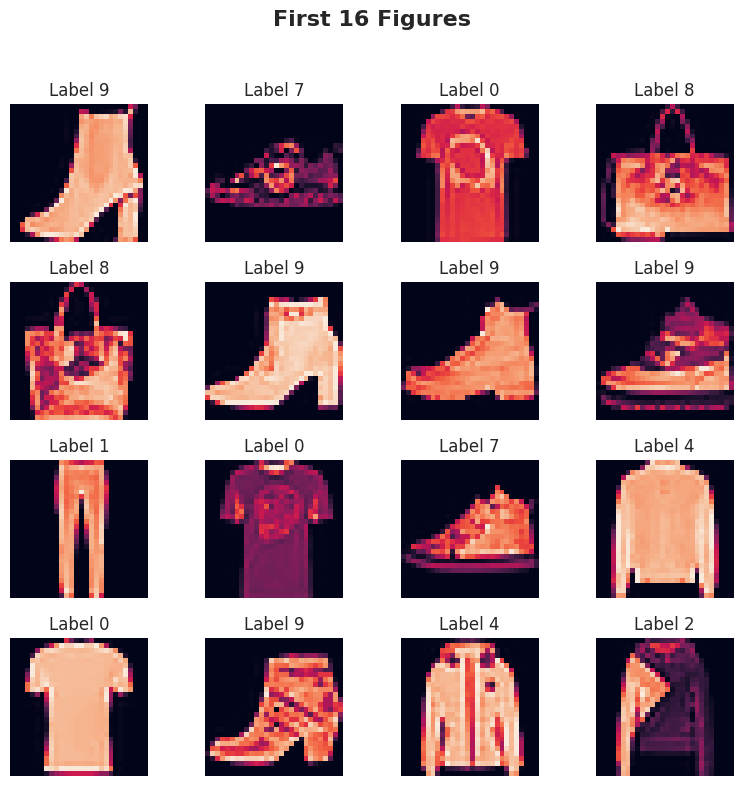

In [4]:
fig, axis = plt.subplots(4, 4, figsize = (8, 8))
fig.suptitle('First 16 Figures', fontweight = 'bold', fontsize = 16)

for i, ax in enumerate(axis.flat):
  img = df.iloc[i, 1:].values.reshape(28, 28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f'Label {df.iloc[i, 0]}')

plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

In [5]:
from numpy.matrixlib import test
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:].values, df.iloc[:, 0].values, test_size = 0.2, random_state = 42)

X_train = X_train / 255.0
X_test = X_test / 255.0

# ****Custom Dataset****

In [6]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype = torch.float32)
    self.labels = torch.tensor(labels, dtype = torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self, idx):

    return self.features[idx], self.labels[idx]

In [7]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

# ****Neural Network Class****

In [8]:
class MyNN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):
      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer
    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self, x):
    return self.model(x)

In [9]:
def objective(trial):

  # Hyperparameters to train
  num_hidden_layers = trial.suggest_int('num_hidden_layers', 2, 5)
  neurons_per_layer = trial.suggest_int('neurons_per_layer', 8, 256, step = 8)
  dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step = 0.1)
  batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128, 256])
  optimizer_name = trial.suggest_categorical('optimizer_name', ['Adam', 'SGD', 'RMSprop', 'AdamW'])
  learning_rate = trial.suggest_float('learning_rate', 1e-3, 1e-1, log = True)
  weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log = True)
  epochs = trial.suggest_int('epochs', 10, 40, step = 5)

  # Data Loader
  train_loader = DataLoader(train_dataset, batch_size = batch_size, pin_memory = True, shuffle = True)
  test_loader = DataLoader(test_dataset, batch_size = batch_size, pin_memory = True, shuffle = False)

  # Model Init
  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate).to(device)
  # Loss Function
  criterion = nn.CrossEntropyLoss()

  # Optimizer Seletion
  if optimizer_name == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr = learning_rate, weight_decay = weight_decay)
  elif optimizer_name == 'SGD':
    optimizer = optim.SGD(model.parameters(), lr = learning_rate, weight_decay = weight_decay)
  elif optimizer_name == 'RMSprop':
    optimizer = optim.RMSprop(model.parameters(), lr = learning_rate, weight_decay = weight_decay)
  elif optimizer_name == 'AdamW':
    optimizer = optim.AdamW(model.parameters(), lr = learning_rate, weight_decay = weight_decay)

  # Training Loop
  for epoch in range(epochs):

    for batch_features, batch_labels in train_loader:
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
      optimizer.zero_grad()
      outputs = model(batch_features)
      loss = criterion(outputs, batch_labels)
      loss.backward()
      optimizer.step()

  # Evaluation on Test Data
  model.eval()
  total, correct = 0, 0
  with torch.no_grad():
    for batch_features, batch_labels in test_loader:
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
      outs = model(batch_features)
      _, preds = torch.max(outs, 1)
      total += batch_labels.shape[0]
      correct += (preds == batch_labels).sum().item()
    accuracy = np.round((correct / total), 4)

  return accuracy


In [10]:
# Optuna Hyperparameter tuning
pruners = optuna.pruners.MedianPruner()
study = optuna.create_study(direction = 'maximize', pruner = pruners)
study.optimize(objective, n_trials = 50)

[I 2026-02-13 10:45:00,074] A new study created in memory with name: no-name-8b4fd597-78f0-4e25-9a96-ef60c8a05f98
[I 2026-02-13 10:45:16,980] Trial 0 finished with value: 0.8233 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 64, 'dropout_rate': 0.2, 'batch_size': 64, 'optimizer_name': 'AdamW', 'learning_rate': 0.0019016900440462158, 'weight_decay': 0.0008147307416826461, 'epochs': 40}. Best is trial 0 with value: 0.8233.
[I 2026-02-13 10:45:21,405] Trial 1 finished with value: 0.8058 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 56, 'dropout_rate': 0.1, 'batch_size': 128, 'optimizer_name': 'RMSprop', 'learning_rate': 0.002364998228835595, 'weight_decay': 9.075370243072303e-05, 'epochs': 30}. Best is trial 0 with value: 0.8233.
[I 2026-02-13 10:45:27,028] Trial 2 finished with value: 0.7792 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 224, 'dropout_rate': 0.30000000000000004, 'batch_size': 128, 'optimizer_name': 'RMSprop', 'learning_rate':

In [11]:
# Get Best Accuracy and Best Parameters
print(f'Best Accuracy : {study.best_value}')
print(f'Best Parameters : {study.best_params}')
best_params = study.best_params

Best Accuracy : 0.855
Best Parameters : {'num_hidden_layers': 4, 'neurons_per_layer': 256, 'dropout_rate': 0.30000000000000004, 'batch_size': 16, 'optimizer_name': 'SGD', 'learning_rate': 0.008618697917270247, 'weight_decay': 0.0004121013980004085, 'epochs': 30}


In [13]:
# Best Params
num_hidden_layers = best_params['num_hidden_layers']
neurons_per_layer = best_params['neurons_per_layer']
dropout_rate = best_params['dropout_rate']
batch_size = best_params['batch_size']
learning_rate = best_params['learning_rate']
weight_decay = best_params['weight_decay']
epochs = best_params['epochs']

# Data Loader
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, pin_memory = True)

# Model Init
input_dim = 784
output_dim = 10

model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate).to(device)

# Optimizer
optimizer = optim.SGD(model.parameters(), lr = learning_rate, weight_decay = weight_decay)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Train Loop
for epoch in range(epochs):
  for bf, bl in train_loader:
    bf, bl = bf.to(device), bl.to(device)
    optimizer.zero_grad()
    tr_out = model(bf)
    tr_loss = criterion(tr_out, bl)
    tr_loss.backward()
    optimizer.step()

model.eval()
total, correct = 0, 0
with torch.no_grad():
  for tr_bf, tr_bl in train_loader:
    tr_bf, tr_bl = tr_bf.to(device), tr_bl.to(device)
    tr_out = model(tr_bf)
    _, tr_pred = torch.max(tr_out, 1)
    total += tr_bl.shape[0]
    correct += (tr_pred == tr_bl).sum().item()
  tr_acc = np.round((correct / total), 4)

total, correct = 0, 0
with torch.no_grad():
  for bfs, bls in test_loader:
    bfs, bls = bfs.to(device), bls.to(device)
    tst_out = model(bfs)
    _, tst_pred = torch.max(tst_out, 1)
    total += bls.shape[0]
    correct += (tst_pred == bls).sum().item()
  tst_acc = np.round((correct / total), 4)

print(f'Training Accuracy : {tr_acc}')
print(f'testing Acuracy : {tst_acc}')

Training Accuracy : 0.9294
testing Acuracy : 0.8392
